# Checkpoint 5 – Statistical Computing with Python

## Análise Estatística do dataset WINES

**Objetivo:** realizar uma análise exploratória utilizando duas variáveis quantitativas do dataset: `Alcohol` e `Malic_Acid`.

A análise foi dividida em:
1. Visualização dos dados;
2. Análise descritiva;
3. Análise probabilística.

Os cálculos foram feitos diretamente a partir dos 178 registros do arquivo `wine-clustering.csv`.


In [1]:
# Importação das bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Leitura do dataset
df = pd.read_csv("wine-clustering.csv")

print("Quantidade de linhas e colunas:", df.shape)
df.head()


Quantidade de linhas e colunas: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Observação inicial

O dataset possui **178 registros e 13 variáveis**. Para esta parte do checkpoint foram escolhidas duas variáveis quantitativas:

- **Alcohol:** teor alcoólico do vinho.
- **Malic_Acid:** quantidade de ácido málico.

A escolha foi feita porque são variáveis numéricas e permitem realizar as medidas estatísticas solicitadas.


## 1. Teor alcoólico (`Alcohol`)

### 1.1 Tabela de distribuição de frequências

In [2]:
# Divisão dos dados em 5 intervalos.
# A frequência mostra quantos vinhos estão em cada intervalo.
# A frequência relativa mostra a participação percentual de cada intervalo.

intervalos = pd.cut(df["Alcohol"], bins=5, include_lowest=True)
tabela_frequencia = (
    intervalos.value_counts()
    .sort_index()
    .rename_axis("Intervalo")
    .reset_index(name="Frequência")
)
tabela_frequencia["Frequência relativa (%)"] = (
    tabela_frequencia["Frequência"] / len(df) * 100
).round(2)

tabela_frequencia


,Intervalo,Frequência,Frequência relativa (%)
0,"(11.025, 11.79]",12,6.74
1,"(11.79, 12.55]",49,27.53
2,"(12.55, 13.31]",48,26.97
3,"(13.31, 14.07]",50,28.09
4,"(14.07, 14.83]",19,10.67


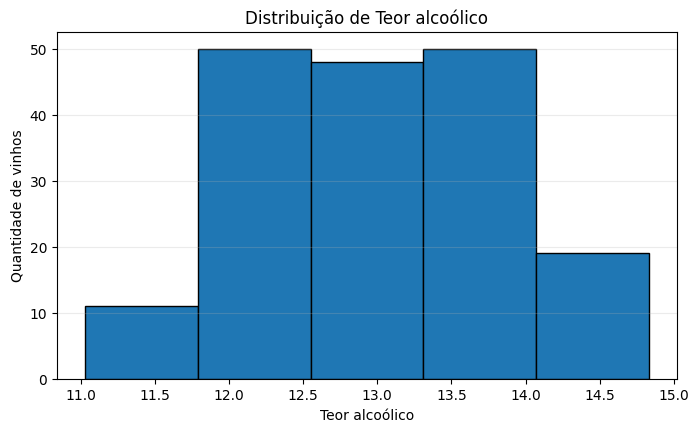

In [3]:
# Gráfico da distribuição de frequências
plt.figure(figsize=(8, 4.5))
plt.hist(df["Alcohol"], bins=5, edgecolor="black")
plt.title("Distribuição de Teor alcoólico")
plt.xlabel("Teor alcoólico")
plt.ylabel("Quantidade de vinhos")
plt.grid(axis="y", alpha=0.25)
plt.show()

# Interpretação:
# O gráfico permite observar em quais intervalos existe maior concentração
# dos valores da variável analisada.


### 1.2 Análise descritiva

In [4]:
# Medidas de tendência central
media = df["Alcohol"].mean()
mediana = df["Alcohol"].median()
moda = df["Alcohol"].mode().iloc[0]

# Medidas de dispersão
minimo = df["Alcohol"].min()
maximo = df["Alcohol"].max()
amplitude = maximo - minimo
variancia = df["Alcohol"].var()
desvio_padrao = df["Alcohol"].std()

# Medidas separatrizes
q1 = df["Alcohol"].quantile(0.25)
q2 = df["Alcohol"].quantile(0.50)
q3 = df["Alcohol"].quantile(0.75)
iqr = q3 - q1

print("Média:", round(media, 4))
print("Mediana:", round(mediana, 4))
print("Moda:", round(moda, 4))
print("Mínimo:", round(minimo, 4))
print("Máximo:", round(maximo, 4))
print("Amplitude:", round(amplitude, 4))
print("Variância:", round(variancia, 4))
print("Desvio padrão:", round(desvio_padrao, 4))
print("Q1:", round(q1, 4))
print("Q2 (mediana):", round(q2, 4))
print("Q3:", round(q3, 4))
print("IQR:", round(iqr, 4))

# Interpretação:
# Média, mediana e moda mostram valores centrais.
# O desvio padrão e a variância mostram a dispersão.
# Os quartis ajudam a entender como os valores estão distribuídos.


Média: 13.0006
Mediana: 13.05
Moda: 12.37
Mínimo: 11.03
Máximo: 14.83
Amplitude: 3.8
Variância: 0.6591
Desvio padrão: 0.8118
Q1: 12.3625
Q2 (mediana): 13.05
Q3: 13.6775
IQR: 1.315


### 1.3 Análise probabilística

In [5]:
# Será utilizada a probabilidade empírica:
# P(A) = quantidade de registros que atendem à condição / total de registros.
# Assim, os cálculos ficam diretamente relacionados aos dados observados.
total = len(df)


In [6]:
cond1 = df["Alcohol"] >= 13
cond2 = df["Alcohol"] < 12.5

p1 = cond1.sum() / total
p2 = cond2.sum() / total

print("P(Alcohol >= 13) =", round(p1, 4), "=", round(p1*100, 2), "%")
print("P(Alcohol < 12,5) =", round(p2, 4), "=", round(p2*100, 2), "%")

# Interpretação:
# 51,69% dos vinhos da amostra possuem teor alcoólico maior ou igual a 13.
# 32,02% possuem teor alcoólico menor que 12,5.


P(Alcohol >= 13) = 0.5169 = 51.69 %
P(Alcohol < 12,5) = 0.3202 = 32.02 %


## 1. Ácido málico (`Malic_Acid`)

### 1.1 Tabela de distribuição de frequências

In [7]:
# Divisão dos dados em 5 intervalos.
# A frequência mostra quantos vinhos estão em cada intervalo.
# A frequência relativa mostra a participação percentual de cada intervalo.

intervalos = pd.cut(df["Malic_Acid"], bins=5, include_lowest=True)
tabela_frequencia = (
    intervalos.value_counts()
    .sort_index()
    .rename_axis("Intervalo")
    .reset_index(name="Frequência")
)
tabela_frequencia["Frequência relativa (%)"] = (
    tabela_frequencia["Frequência"] / len(df) * 100
).round(2)

tabela_frequencia


,Intervalo,Frequência,Frequência relativa (%)
0,"(0.734, 1.752]",77,43.26
1,"(1.752, 2.764]",49,27.53
2,"(2.764, 3.776]",25,14.04
3,"(3.776, 4.788]",21,11.80
4,"(4.788, 5.8]",6,3.37


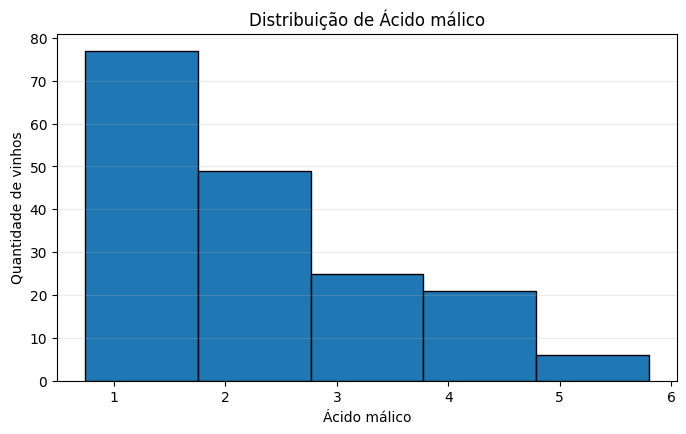

In [8]:
# Gráfico da distribuição de frequências
plt.figure(figsize=(8, 4.5))
plt.hist(df["Malic_Acid"], bins=5, edgecolor="black")
plt.title("Distribuição de Ácido málico")
plt.xlabel("Ácido málico")
plt.ylabel("Quantidade de vinhos")
plt.grid(axis="y", alpha=0.25)
plt.show()

# Interpretação:
# O gráfico permite observar em quais intervalos existe maior concentração
# dos valores da variável analisada.


### 1.2 Análise descritiva

In [9]:
# Medidas de tendência central
media = df["Malic_Acid"].mean()
mediana = df["Malic_Acid"].median()
moda = df["Malic_Acid"].mode().iloc[0]

# Medidas de dispersão
minimo = df["Malic_Acid"].min()
maximo = df["Malic_Acid"].max()
amplitude = maximo - minimo
variancia = df["Malic_Acid"].var()
desvio_padrao = df["Malic_Acid"].std()

# Medidas separatrizes
q1 = df["Malic_Acid"].quantile(0.25)
q2 = df["Malic_Acid"].quantile(0.50)
q3 = df["Malic_Acid"].quantile(0.75)
iqr = q3 - q1

print("Média:", round(media, 4))
print("Mediana:", round(mediana, 4))
print("Moda:", round(moda, 4))
print("Mínimo:", round(minimo, 4))
print("Máximo:", round(maximo, 4))
print("Amplitude:", round(amplitude, 4))
print("Variância:", round(variancia, 4))
print("Desvio padrão:", round(desvio_padrao, 4))
print("Q1:", round(q1, 4))
print("Q2 (mediana):", round(q2, 4))
print("Q3:", round(q3, 4))
print("IQR:", round(iqr, 4))

# Interpretação:
# Média, mediana e moda mostram valores centrais.
# O desvio padrão e a variância mostram a dispersão.
# Os quartis ajudam a entender como os valores estão distribuídos.


Média: 2.3363
Mediana: 1.865
Moda: 1.73
Mínimo: 0.74
Máximo: 5.8
Amplitude: 5.06
Variância: 1.248
Desvio padrão: 1.1171
Q1: 1.6025
Q2 (mediana): 1.865
Q3: 3.0825
IQR: 1.48


### 1.3 Análise probabilística

In [10]:
# Será utilizada a probabilidade empírica:
# P(A) = quantidade de registros que atendem à condição / total de registros.
# Assim, os cálculos ficam diretamente relacionados aos dados observados.
total = len(df)


In [11]:
cond1 = df["Malic_Acid"] <= 2
cond2 = df["Malic_Acid"] > 3

p1 = cond1.sum() / total
p2 = cond2.sum() / total

print("P(Malic_Acid <= 2) =", round(p1, 4), "=", round(p1*100, 2), "%")
print("P(Malic_Acid > 3) =", round(p2, 4), "=", round(p2*100, 2), "%")

# Interpretação:
# 56,18% dos vinhos possuem ácido málico menor ou igual a 2.
# 26,40% possuem ácido málico maior que 3.


P(Malic_Acid <= 2) = 0.5618 = 56.18 %
P(Malic_Acid > 3) = 0.264 = 26.4 %


## Conclusão

A análise mostrou que as duas variáveis apresentam distribuições diferentes.

No caso de **Alcohol**, os valores ficam concentrados próximos de 13, com média de aproximadamente 13,00 e desvio padrão de aproximadamente 0,81. Isso indica uma variação relativamente pequena em torno da média.

Para **Malic_Acid**, a média foi de aproximadamente 2,34 e o desvio padrão foi de aproximadamente 1,12. Nesse caso, a variação dos valores é maior.

Os quartis ajudaram a identificar como os dados estão distribuídos. Na análise probabilística, foram utilizadas probabilidades empíricas, calculadas diretamente a partir dos registros do dataset.

Dessa forma, foi possível realizar a análise exploratória solicitada utilizando conceitos básicos de estatística e Python.
